# Heat Equation with PINNs

This notebook demonstrates how to solve the **1D heat equation** using Physics-Informed Neural Networks (PINNs).

## The Problem

We solve the heat diffusion equation:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

with:
- **Domain**: $x \in [0, 1]$, $t \in [0, 1]$
- **Boundary conditions**: $u(0, t) = u(1, t) = 0$
- **Initial condition**: $u(x, 0) = \sin(\pi x)$

## Analytical Solution

The analytical solution is:

$$u(x, t) = e^{-\alpha \pi^2 t} \sin(\pi x)$$

We will compare our PINN solution against this analytical result.

In [11]:
import pinns
import torch
import numpy as np
import matplotlib.pyplot as plt

## 1. Define Parameters

The thermal diffusivity $\alpha$ controls how fast heat spreads. A larger value means faster diffusion.

In [12]:
# Physical parameter
alpha = 0.01  # Thermal diffusivity

# Domain bounds
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

## 2. Define the Domain

We create a 2D domain for $(x, t)$ and use Latin Hypercube Sampling for better coverage of the domain.

In [13]:
domain = pinns.DomainCubic(
    xmin=[x_min, t_min],
    xmax=[x_max, t_max],
    sampling_method="latin_hypercube"
)

print(f"Domain dimensions: {domain.n_dims}")
print(f"Domain bounds: x ∈ [{x_min}, {x_max}], t ∈ [{t_min}, {t_max}]")

Domain dimensions: 2
Domain bounds: x ∈ [0.0, 1.0], t ∈ [0.0, 1.0]


## 3. Add Boundary Conditions

We have three boundary conditions:
1. **Left boundary**: $u(0, t) = 0$
2. **Right boundary**: $u(1, t) = 0$
3. **Initial condition**: $u(x, 0) = \sin(\pi x)$

In [14]:
# Left boundary: u(0, t) = 0
domain.add_dirichlet(
    boundary=(0, None),  # x = x_min, all t
    value=0.0,
    component=0,
    name="left"
)

# Right boundary: u(1, t) = 0
domain.add_dirichlet(
    boundary=(1, None),  # x = x_max, all t
    value=0.0,
    component=0,
    name="right"
)

# Initial condition: u(x, 0) = sin(pi * x)
# Note: value function receives numpy array, so use np.sin
domain.add_dirichlet(
    boundary=(None, 0),  # all x, t = t_min
    value=lambda x: np.sin(np.pi * x[:, 0:1]),
    component=0,
    name="initial"
)

print(f"Number of boundary conditions: {len(domain.boundary_conditions)}")

Number of boundary conditions: 3


## 4. Define the PDE Residual

The PDE residual is the equation that should equal zero when the PDE is satisfied:

$$\text{residual} = \frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2} = 0$$

In [15]:
def heat_equation(X, V, params):
    """
    Heat equation residual.
    
    Args:
        X: Input tensor (batch, 2) with columns [x, t]
        V: Network output (batch, 1) with column [u]
        params: Dictionary with 'fixed', 'infer', 'internal' keys
    
    Returns:
        Residual tensor (should be zero when PDE is satisfied)
    """
    alpha = params["fixed"]["alpha"]
    
    # Compute derivatives using automatic differentiation
    u_t = pinns.derivative(V, X, component=0, order=(1,))    # ∂u/∂t
    u_xx = pinns.derivative(V, X, component=0, order=(0, 0)) # ∂²u/∂x²
    
    # Heat equation: u_t = alpha * u_xx
    return u_t - alpha * u_xx

## 5. Define the Analytical Solution (for comparison)

Since we know the analytical solution, we can provide it to the trainer for error visualization.

In [16]:
def analytical_solution(X, params):
    """
    Analytical solution: u(x, t) = exp(-alpha * pi^2 * t) * sin(pi * x)
    """
    alpha = params["fixed"]["alpha"]
    x = X[:, 0:1]
    t = X[:, 1:2]
    
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

## 6. Create the Problem

The `Problem` class combines the domain, PDE, and parameters into a single object.

In [17]:
problem = pinns.Problem(
    domain=domain,
    pde_fn=heat_equation,
    input_names=["x", "t"],
    output_names=["u"],
    output_range=(0, 1),  # Expected output range for normalization
    params={"alpha": alpha},
    solution=analytical_solution  # For error tracking
)

print(f"Problem: {problem.n_dims}D input → {problem.n_outputs}D output")

Problem: 2D input → 1D output


## 7. Create the Neural Network

We use a fully-connected network with 3 hidden layers of 64 neurons each.

The `tanh` activation is commonly used in PINNs as it provides smooth derivatives.

In [18]:
network = pinns.FNN(
    layer_sizes=[2, 64, 64, 64, 1],  # 2 inputs → 64 → 64 → 64 → 1 output
    activation="tanh",
    normalize_input=True,
    unnormalize_output=True
)

# Count parameters
n_params = sum(p.numel() for p in network.parameters())
print(f"Network architecture: {network.layer_sizes}")
print(f"Total parameters: {n_params:,}")

Network architecture: [2, 64, 64, 64, 1]
Total parameters: 8,577


## 8. Create the Trainer

The `Trainer` handles the training loop, sampling, and visualization.

In [19]:
trainer = pinns.Trainer(problem, network)
print(f"Training on device: {trainer.device}")

Training on device: cuda


## 9. Configure and Train

We use:
- More samples for the PDE (interior) than boundaries
- Higher weights for boundary conditions to enforce them more strongly
- Adam optimizer for initial training

Epoch     0 | Loss: 1.2944e+01 | PDE: 3.66e-01 | BCs: [1.55e+00, 4.75e+00, 6.28e+00] | Error: 4.99e-01


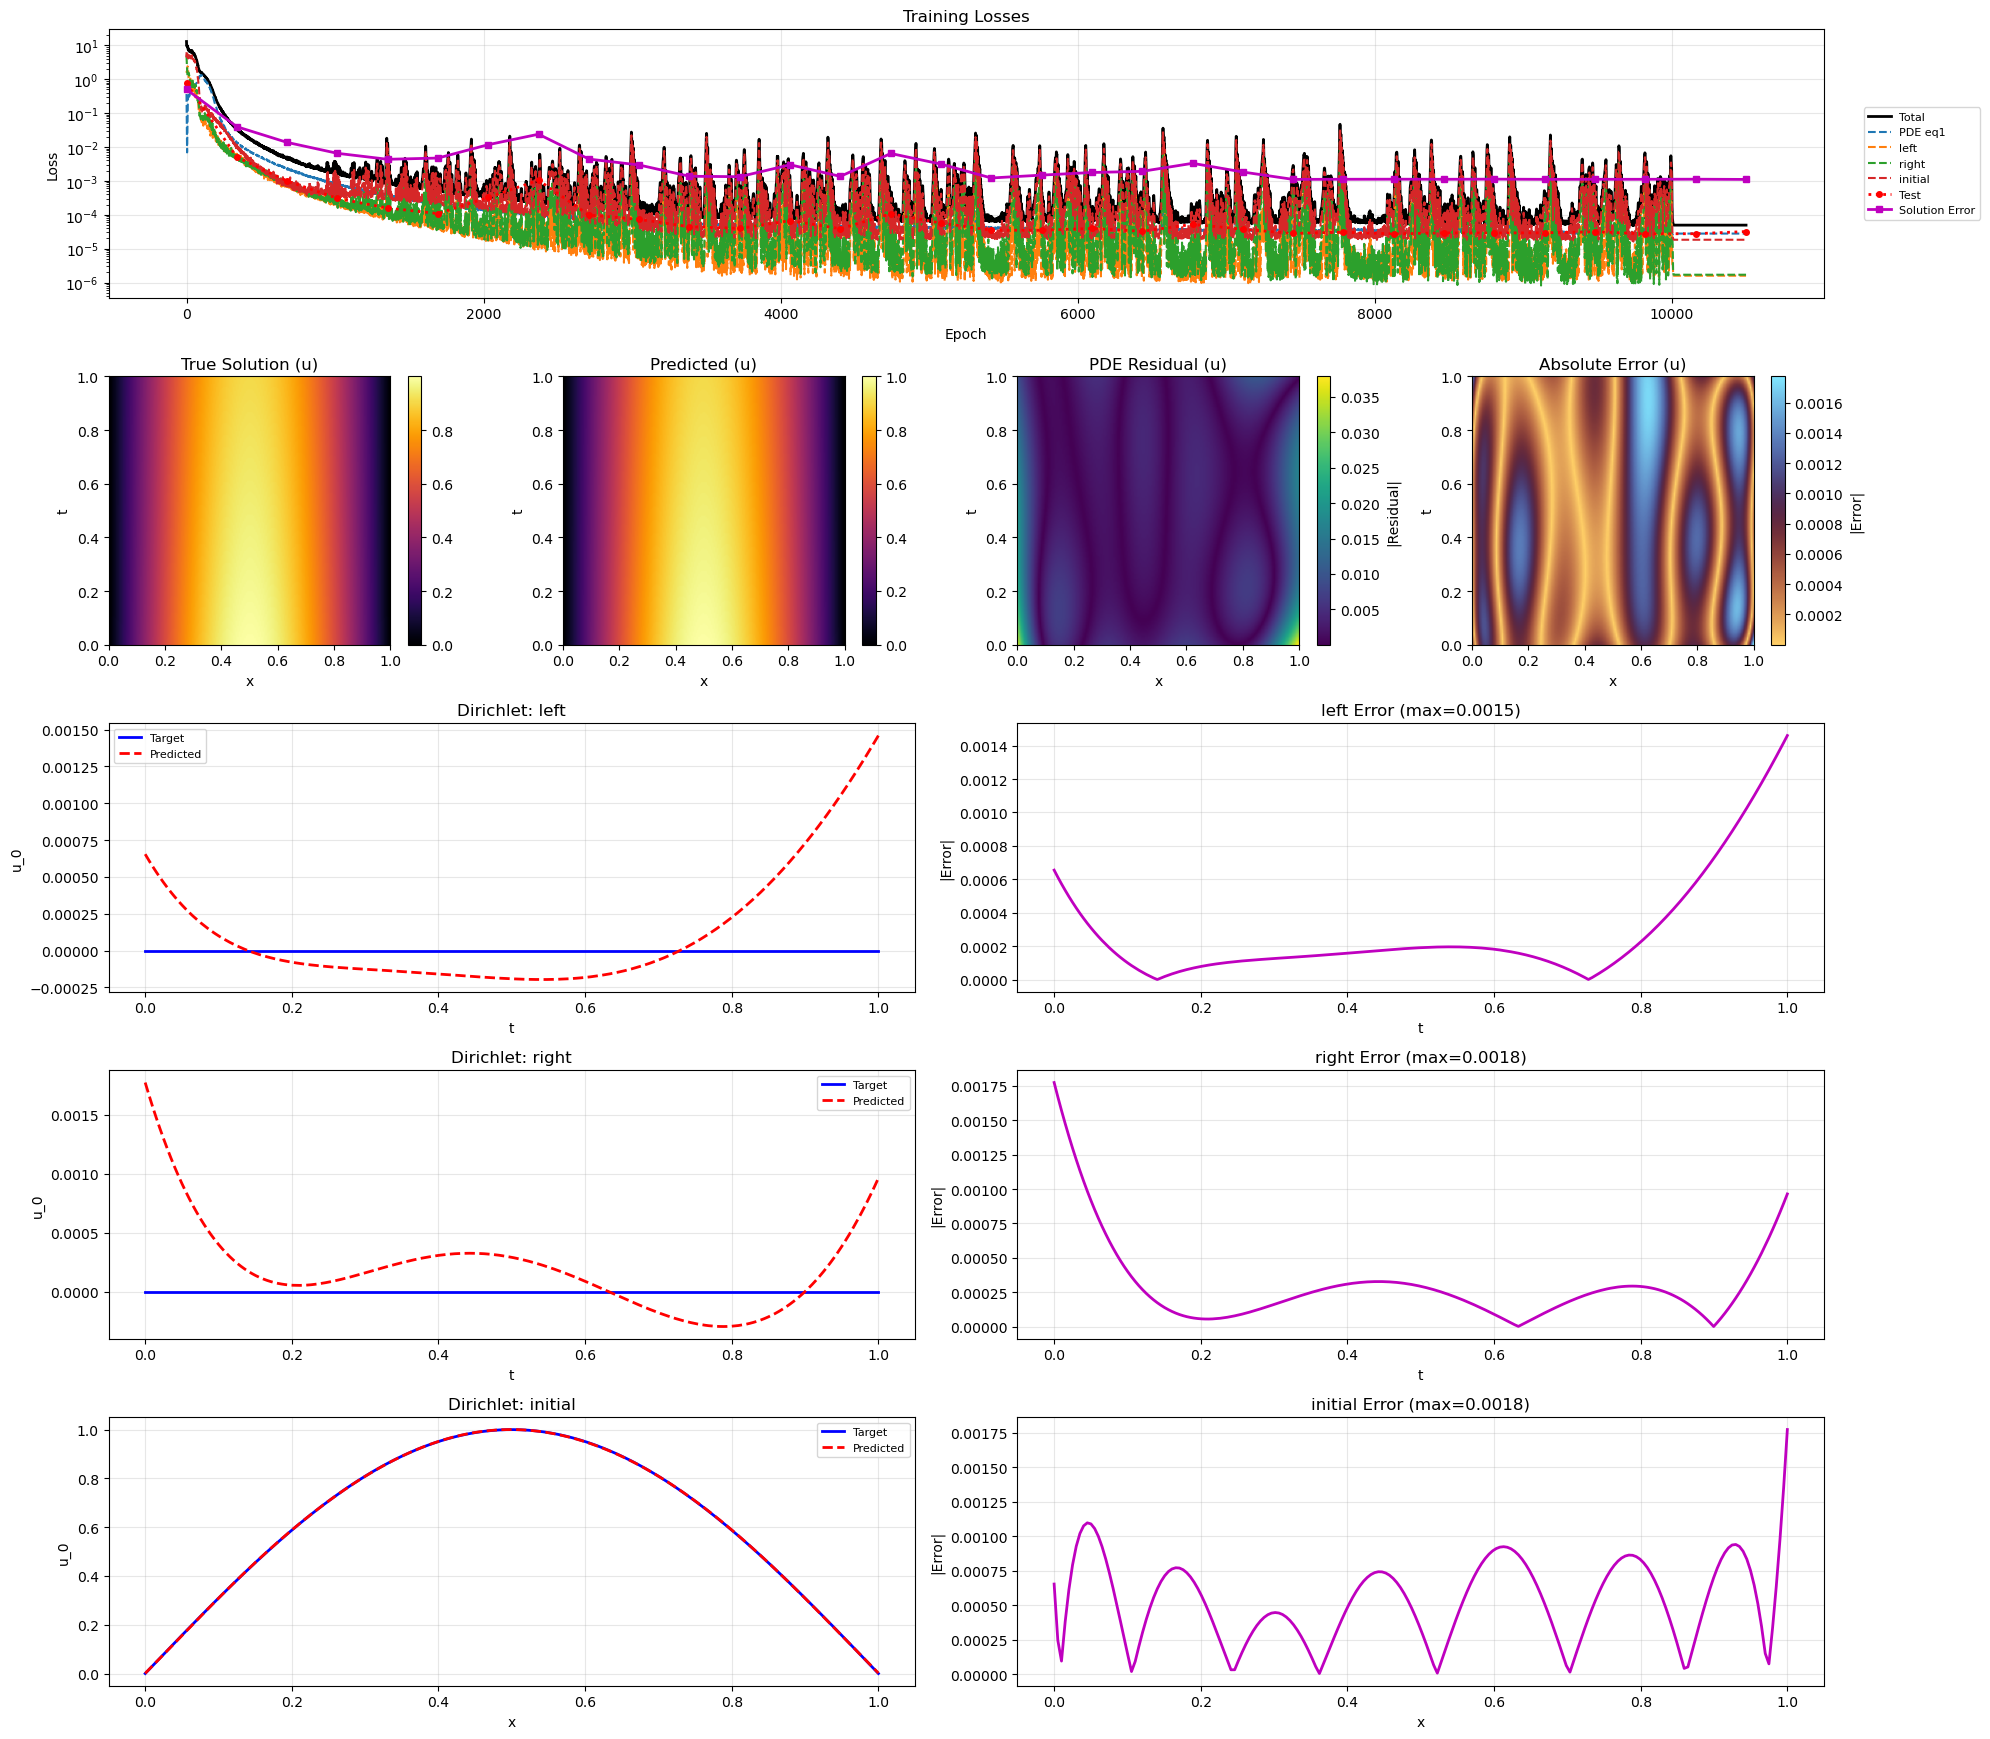

Epoch   500 | Loss: 1.0968e-02 | PDE: 4.91e-03 | BCs: [1.79e-03, 2.00e-03, 2.28e-03] | Error: 3.98e-02
Epoch  1000 | Loss: 3.2271e-03 | PDE: 7.79e-04 | BCs: [3.18e-04, 3.90e-04, 1.74e-03] | Error: 1.37e-02
Epoch  1500 | Loss: 9.4160e-04 | PDE: 2.85e-04 | BCs: [1.15e-04, 7.48e-05, 4.67e-04] | Error: 6.50e-03
Epoch  2000 | Loss: 3.4998e-04 | PDE: 1.45e-04 | BCs: [2.35e-05, 2.64e-05, 1.55e-04] | Error: 4.33e-03
Epoch  2500 | Loss: 3.8253e-04 | PDE: 1.01e-04 | BCs: [4.28e-05, 3.45e-05, 2.04e-04] | Error: 4.71e-03
Epoch  3000 | Loss: 1.7416e-03 | PDE: 6.48e-05 | BCs: [3.34e-04, 2.74e-05, 1.32e-03] | Error: 1.17e-02
Epoch  3500 | Loss: 2.1935e-02 | PDE: 2.12e-04 | BCs: [1.69e-03, 2.95e-03, 1.71e-02] | Error: 2.38e-02
Epoch  4000 | Loss: 1.1288e-03 | PDE: 4.51e-05 | BCs: [1.64e-04, 6.09e-05, 8.59e-04] | Error: 4.40e-03
Epoch  4500 | Loss: 9.0103e-04 | PDE: 4.18e-05 | BCs: [4.51e-06, 2.06e-04, 6.49e-04] | Error: 2.94e-03
Epoch  5000 | Loss: 6.6764e-05 | PDE: 4.17e-05 | BCs: [2.31e-06, 3.81e-06

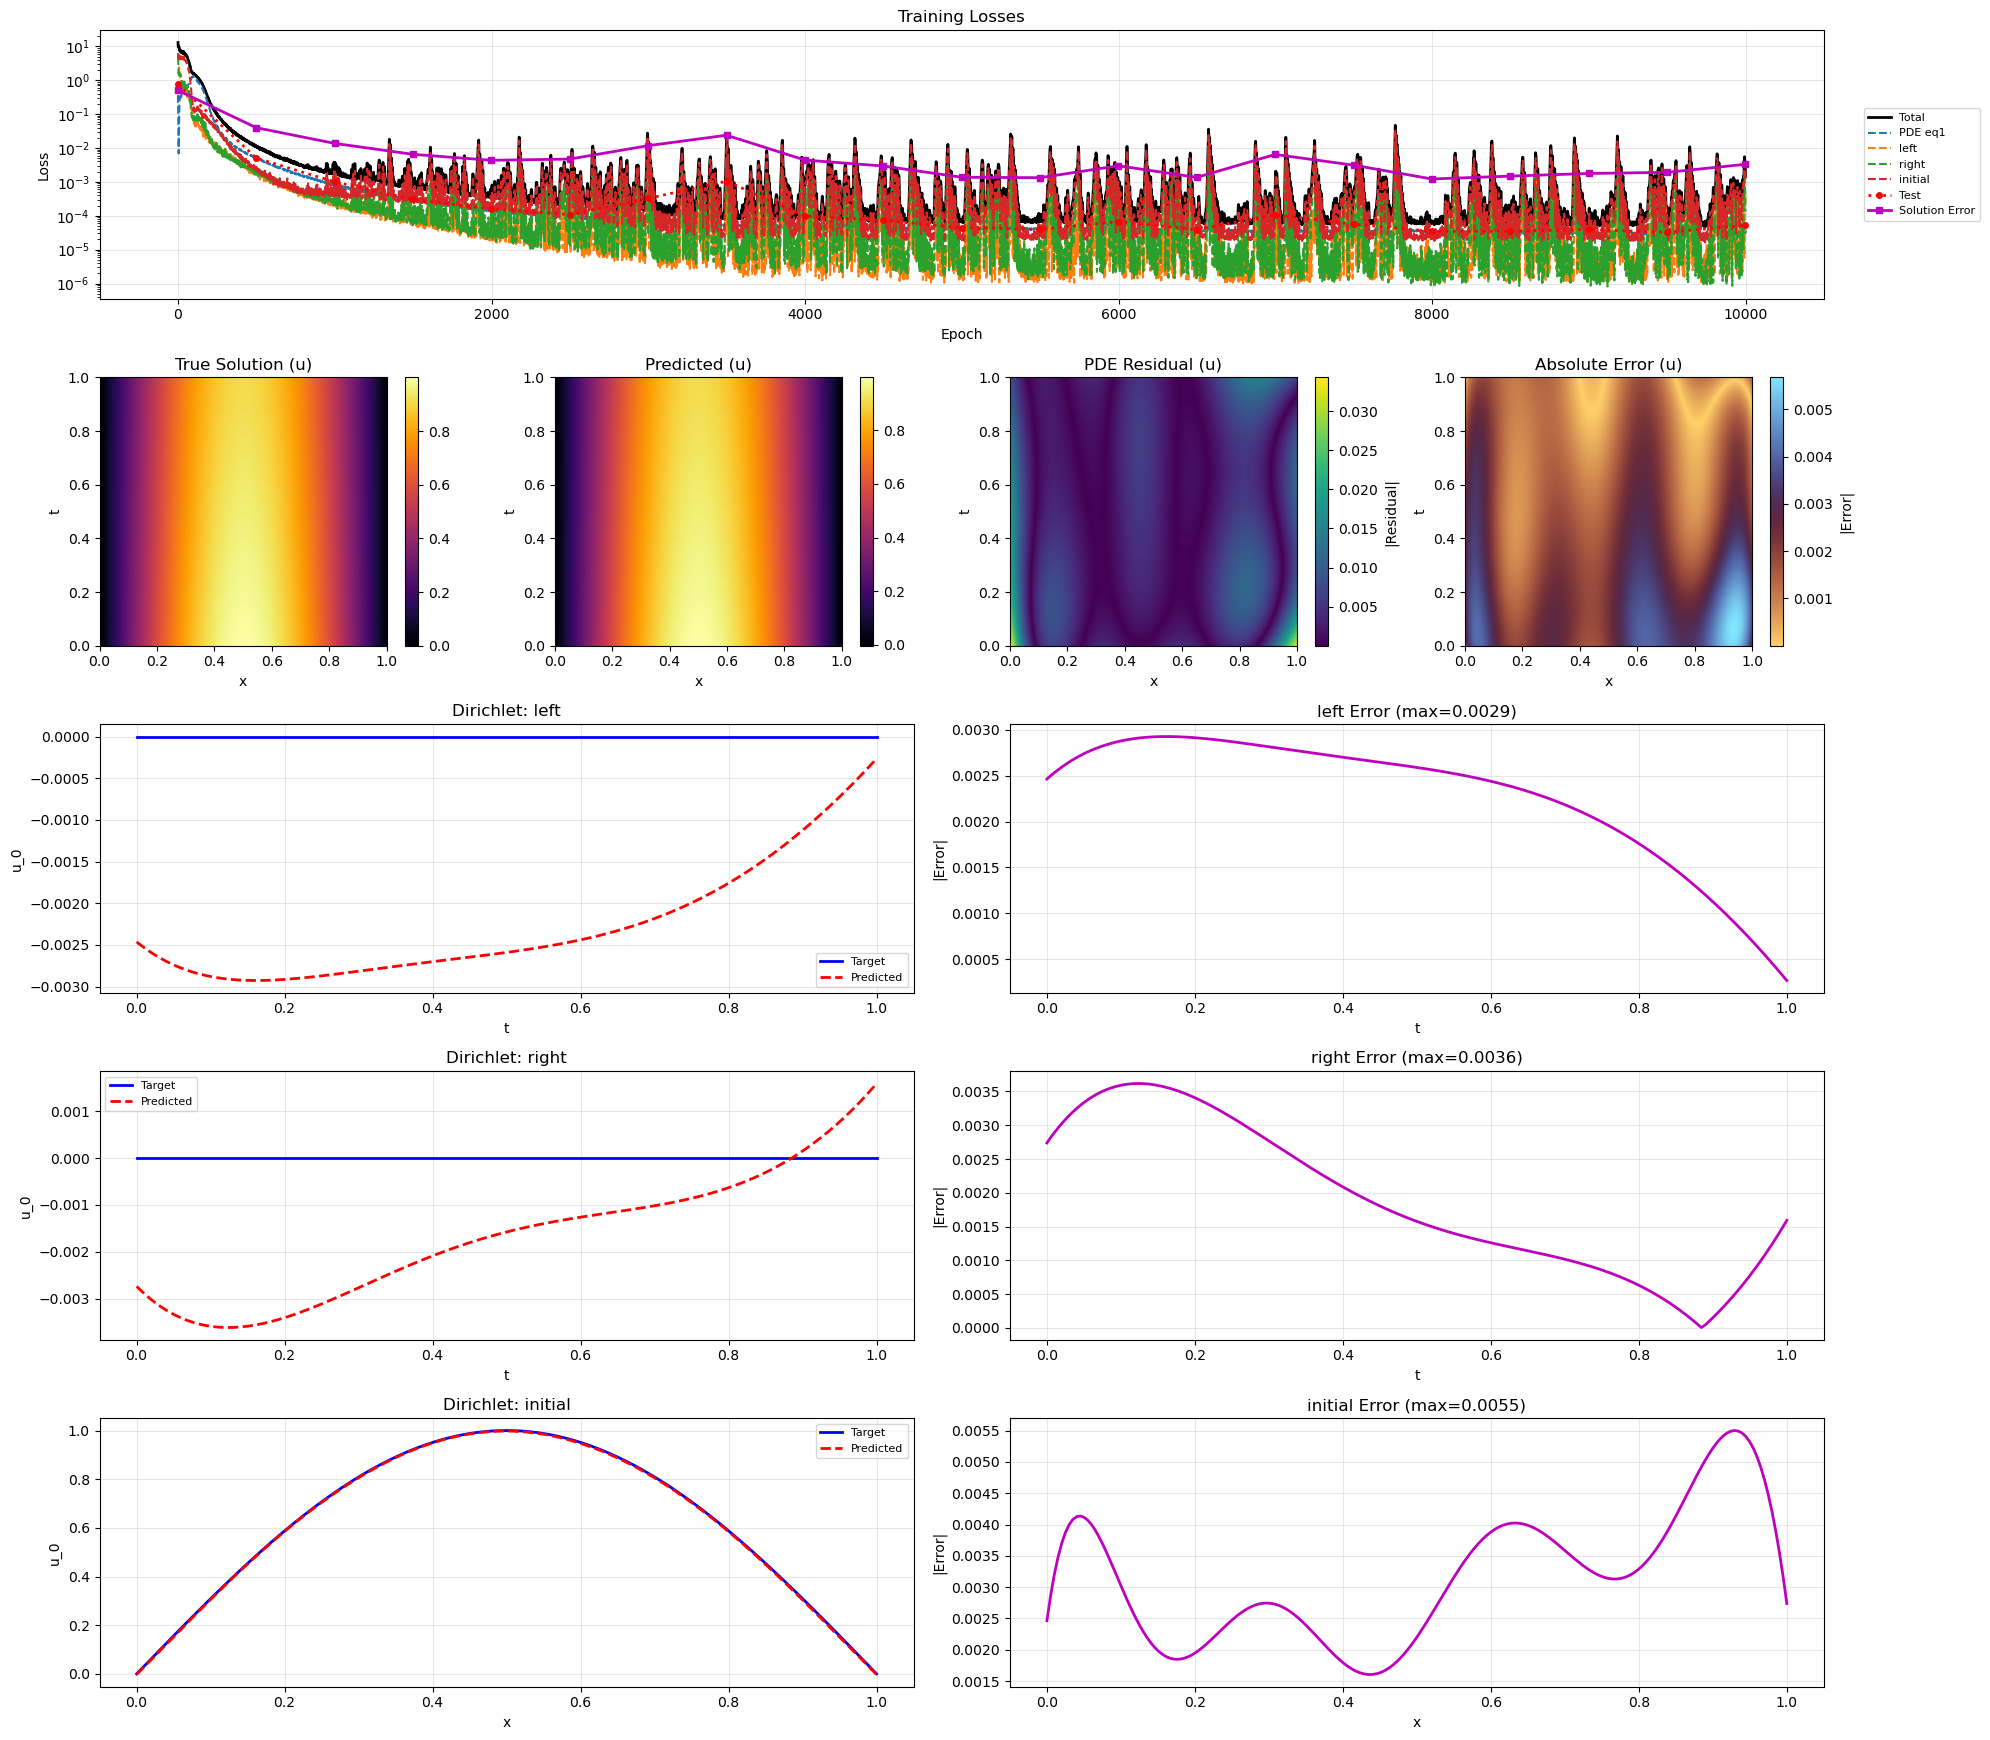

In [20]:
trainer.compile(
    train_samples={
        "pde": 5000,      # Interior PDE samples
        "left": 200,      # Left boundary samples
        "right": 200,     # Right boundary samples
        "initial": 500    # Initial condition samples
    },
    test_samples={
        "pde": 500,
        "left": 50,
        "right": 50,
        "initial": 100
    },
    weights={
        "pde": 1.0,
        "left": 10.0,     # Higher weight for BCs
        "right": 10.0,
        "initial": 50.0   # Highest weight for IC
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    show_plots=True
)

trainer.train()

## 10. Fine-tune with L-BFGS (Optional)

L-BFGS often provides better convergence for the final refinement phase.

In [21]:
trainer.compile(
    optimizer="lbfgs",
    epochs=500,
    print_each=50,
    show_plots=True
)

trainer.train()

Epoch 10000 | Loss: 2.6747e-04 | PDE: 2.84e-05 | BCs: [1.80e-05, 1.44e-05, 2.07e-04] | Error: 1.83e-03


/home/gatocor/Documentos/PINN/pinn_models/pinns/trainer.py:837: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1750 with 12 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)
/home/gatocor/Documentos/PINN/pinn_models/pinns/trainer.py:797: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1750 with 13 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)
/home/gatocor/Documentos/PINN/pinn_models/pinns/trainer.py:1150: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1750 with 14 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax, label='|Residual|')
/home/gatocor/Documentos/PINN/pinn_models/pinns/trainer.py:1069: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1750 with 15 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorb

Epoch 10050 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.11e-03
Epoch 10100 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.12e-03
Epoch 10150 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.12e-03
Epoch 10200 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.11e-03
Epoch 10250 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.12e-03
Epoch 10300 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.11e-03
Epoch 10350 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.11e-03
Epoch 10400 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.11e-03
Epoch 10450 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06, 1.83e-05] | Error: 1.12e-03
Epoch 10499 | Loss: 4.9444e-05 | PDE: 2.78e-05 | BCs: [1.59e-06, 1.70e-06

<Figure size 640x480 with 0 Axes>